# Modelo híbrido

La propuesta de modelo híbrido propuesto consiste en híbrido LSTM con atención + un clasificador XGBoost, este arquitectura combina las fortalezas de las redes neuronales recurrentes (RNNs) con mecanismos de atención y el algoritmo de boosting de gradiente XGBoost para tareas de clasificación. Esta arquitectura, tiene los siguientes componentes:


1. **Capa LSTM (Long Short-Term Memory):**

- *Propósito:* Captura las dependencias secuenciales en los datos de entrada. Las LSTM son especialmente efectivas para manejar secuencias largas, ya que mitigan el problema del desvanecimiento del gradiente presente en las RNNs tradicionales.

- *Funcionamiento:* Utilizan celdas de memoria y puertas (input, forget, output) para controlar el flujo de información a lo largo de la secuencia, permitiendo recordar información relevante durante períodos extensos.
Salida: Produce una secuencia de estados ocultos, donde cada estado representa la información aprendida hasta ese punto en la secuencia.


2. **Mecanismo de Atención:**

- *Propósito:* Permite al modelo enfocarse en las partes más relevantes de la secuencia de salida de la LSTM al tomar una decisión. No todos los pasos en una secuencia son igualmente importantes para la clasificación final.

- *Funcionamiento:* Asigna pesos de "atención" a los diferentes estados ocultos de la LSTM. Estos pesos indican la importancia relativa de cada paso de la secuencia para la tarea actual. Luego, se calcula una suma ponderada de estos estados ocultos, creando un "vector de contexto" o "representación atencional" de la secuencia.

- *Salida:* Un vector de características de tamaño fijo que resume la información más importante de la secuencia de entrada, ponderada por su relevancia.


3. **Clasificador XGBoost**:

- *Propósito*: Realiza la tarea final de clasificación utilizando el vector de características generado por la combinación de la LSTM con el mecanismo de atención.

- *Funcinamiento*: XGBoost es un algoritmo de boosting de gradiente que construye múltiples árboles de decisión secuencialmente. Cada nuevo árbol corrige los errores cometidos por los árboles anteriores, lo que lleva a un modelo final robusto y preciso. Utiliza regularización para prevenir el sobreajuste y técnicas para manejar datos faltantes y optimizar la velocidad de procesamiento.

- *Entrada*: El vector de contexto o representación atencional proveniente de la capa de atención aplicada a la salida de la LSTM.

- *Salida*: La predicción de clase para la secuencia de entrada.


In [ ]:
# Basic python libraries
import os
import time
import joblib
import pandas as pd
import numpy as np

# Visualizarition libraries
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    confusion_matrix, classification_report, recall_score, precision_score, accuracy_score, f1_score, roc_auc_score, make_scorer
)

# Modeling
import xgboost as xgb
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks


In [2]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    from google.colab import userdata

    train_path = userdata.get('mitbih_train')
    df_train = pd.read_csv(train_path, header=None)

    test_path = userdata.get('mitbih_test')
    df_test = pd.read_csv(test_path, header=None)
except:
    train_path = "../../proyecto/data/mitbih_train.csv"
    df_train = pd.read_csv(train_path, header=None)

    test_path = "../../proyecto/data/mitbih_test.csv"
    df_test = pd.read_csv(test_path, header=None)

## Preparación de los Datos 

In [4]:
X = df_train.iloc[:, :-1].values.reshape((-1, 187, 1)).astype(np.float32)
X_test_final = df_test.iloc[:, :-1].values.reshape((-1, 187, 1)).astype(np.float32)

# Etiquetas (y) - Convertir a etiquetas numéricas para XGBoost
y_labels = df_train.iloc[:, -1].values.astype(int)
y_test_labels = df_test.iloc[:, -1].values.astype(int)

# División Train/Validation (para el extractor LSTM y potencialmente XGBoost)
X_train, X_val, y_train_labels, y_val_labels = train_test_split(
    X, y_labels,
    test_size=0.2,
    stratify=y_labels, # Estratificar con etiquetas numéricas
    random_state=42
)

print(f"Forma X_train: {X_train.shape}")
print(f"Forma y_train_labels: {y_train_labels.shape}")
print(f"Forma X_val: {X_val.shape}")
print(f"Forma y_val_labels: {y_val_labels.shape}")
print(f"Forma X_test_final: {X_test_final.shape}")
print(f"Forma y_test_labels: {y_test_labels.shape}")
num_classes = len(np.unique(y_train_labels))
print(f"Número de clases: {num_classes}")

Forma X_train: (70043, 187, 1)
Forma y_train_labels: (70043,)
Forma X_val: (17511, 187, 1)
Forma y_val_labels: (17511,)
Forma X_test_final: (21892, 187, 1)
Forma y_test_labels: (21892,)
Número de clases detectadas: 5


## Entrenamiento del modelo híbrido

### Modelo LSTM con atención

In [5]:
def build_lstm_attention_classifier(input_shape, num_classes, lstm_units=64, dense_units=64):
    """
    Construye el modelo LSTM con Atención COMPLETO (incluyendo cabeza de clasificación)
    para ser entrenado.
    """
    inputs = keras.Input(shape=input_shape)

    # Capa LSTM
    lstm_out = layers.LSTM(lstm_units, return_sequences=True)(inputs)

    # Capa de Atención
    query = lstm_out
    value = lstm_out
    attention_out = layers.AdditiveAttention(name='attention_layer')([query, value])

    # Reducción de dimensión
    pool_out = layers.GlobalAveragePooling1D()(attention_out)

    # Capa Densa ANTES de la clasificación (esta será la salida del extractor)
    feature_vector = layers.Dense(dense_units, activation='relu', name='feature_vector_layer')(pool_out)
    # Añadir Dropout si se desea regularizar el entrenamiento del extractor
    feature_vector_dropout = layers.Dropout(0.3)(feature_vector) # Dropout opcional

    # Cabeza de Clasificación (para entrenar el modelo)
    outputs = layers.Dense(num_classes, activation='softmax', name='classification_head')(feature_vector_dropout) # Usar feature_vector_dropout si se añadió dropout

    # Crear el modelo de entrenamiento completo
    training_model = models.Model(inputs=inputs, outputs=outputs)

    return training_model

input_shape = (X_train.shape[1], X_train.shape[2]) # (187, 1)

# Construir el modelo clasificador para entrenarlo
lstm_classifier_model = build_lstm_attention_classifier(
    input_shape=input_shape,
    num_classes=num_classes, # Pasar el número de clases
    lstm_units=100,          # Hiperparámetro ajustable
    dense_units=50           # Hiperparámetro ajustable (tamaño final de características)
)

# Compilar el modelo para el entrenamiento
lstm_classifier_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3), # Optimizador Adam con tasa de aprendizaje
    loss='sparse_categorical_crossentropy', # Loss para etiquetas enteras
    metrics=['accuracy'] # Métrica para monitorear
)

print("\n--- Resumen del Modelo Clasificador LSTM+Atención (para entrenamiento) ---")
lstm_classifier_model.summary()


--- Resumen del Modelo Clasificador LSTM+Atención (para entrenamiento) ---
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 187, 1)]     0           []                               
                                                                                                  
 lstm (LSTM)                    (None, 187, 100)     40800       ['input_1[0][0]']                
                                                                                                  
 attention_layer (AdditiveAtten  (None, 187, 100)    100         ['lstm[0][0]',                   
 tion)                                                            'lstm[0][0]']                   
                                                                                                  
 global_average_po

In [6]:
print("\n--- Entrenando el Modelo LSTM+Atención ---")

early_stopping = callbacks.EarlyStopping(
    monitor='val_loss', # Monitorear la pérdida en el set de validación
    patience=10,        # Número de épocas sin mejora antes de detener
    restore_best_weights=True, # Restaurar pesos del mejor epoch
    verbose=1
)

# Entrenar el modelo
history = lstm_classifier_model.fit(
    X_train, y_train_labels,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val_labels),
    callbacks=[early_stopping],
    verbose=1
)


--- Entrenando el Modelo LSTM+Atención ---
Epoch 1/50
1095/1095 [==============================] - 130s 112ms/step - loss: 0.5865 - accuracy: 0.8387 - val_loss: 0.4382 - val_accuracy: 0.8776
Epoch 2/50
1095/1095 [==============================] - 122s 111ms/step - loss: 0.4069 - accuracy: 0.8923 - val_loss: 0.3704 - val_accuracy: 0.9055
Epoch 3/50
1095/1095 [==============================] - 123s 112ms/step - loss: 0.3178 - accuracy: 0.9196 - val_loss: 0.2750 - val_accuracy: 0.9267
Epoch 4/50
1095/1095 [==============================] - 122s 111ms/step - loss: 0.2646 - accuracy: 0.9325 - val_loss: 0.2134 - val_accuracy: 0.9451
Epoch 5/50
1095/1095 [==============================] - 113s 103ms/step - loss: 0.2431 - accuracy: 0.9363 - val_loss: 0.2258 - val_accuracy: 0.9358
Epoch 6/50
1095/1095 [==============================] - 106s 97ms/step - loss: 0.2102 - accuracy: 0.9441 - val_loss: 0.1932 - val_accuracy: 0.9457
Epoch 7/50
1095/1095 [==============================] - 106s 97ms/ste

In [7]:
# Guardar modelo
model_name = "lstm_attention_classifier_model"
os.makedirs("models", exist_ok=True)
tf.keras.models.save_model(lstm_classifier_model, f'models/{model_name}.h5')

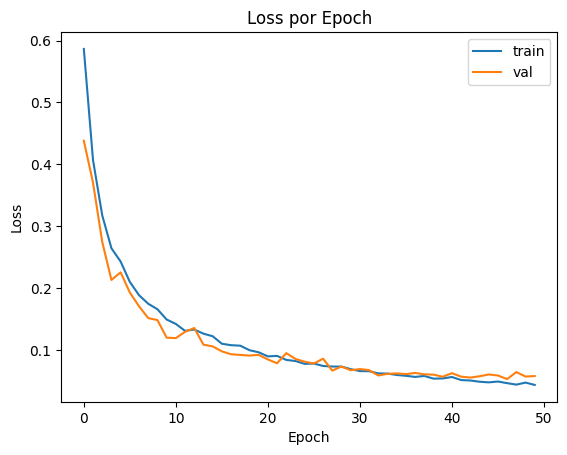

In [8]:
# Curva de pérdida
plt.figure()
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss por Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

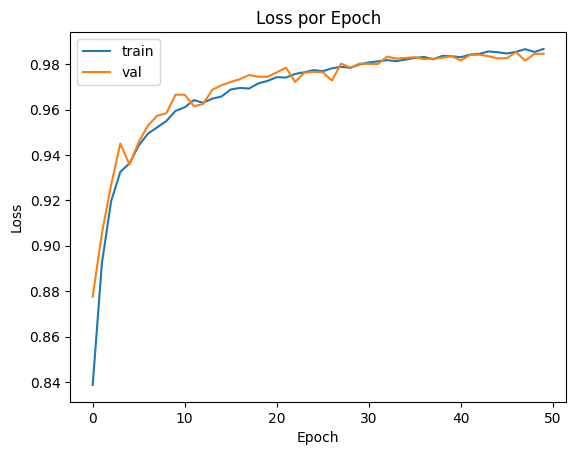

In [285]:
# Curva de pérdida
plt.figure()
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Loss por Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [58]:
predicted_probabilities_lstm = lstm_classifier_model.predict(X_test_final)
predicted_labels_lstm = np.argmax(predicted_probabilities_lstm, axis=1)
print(f"Predicciones LSTM: {predicted_labels_lstm.shape}")

685/685 [==============================] - 22s 30ms/step
Predicciones LSTM: (21892,)


In [59]:
# Calcular Recall Macro
recall_macro_lstm = recall_score(y_test_labels, predicted_labels_lstm, average='macro')
print(f"Recall Macro (LSTM+Atención en Test): {recall_macro_lstm:.4f}")

Recall Macro (LSTM+Atención en Test): 0.8570


### Modelo Extractor con Pesos Entrenados

In [9]:
extractor_model_trained = models.Model(
    inputs=lstm_classifier_model.input, # La misma entrada que el modelo original
    outputs=lstm_classifier_model.get_layer('feature_vector_layer').output # Salida del vector de características
)

print("\n--- Resumen del Modelo Extractor ---")
extractor_model_trained.summary() # Resumen del modelo extractor que utiliza los pesos entrenados con el lstm_classifier_model


--- Resumen del Modelo Extractor ---
Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 187, 1)]     0           []                               
                                                                                                  
 lstm (LSTM)                    (None, 187, 100)     40800       ['input_1[0][0]']                
                                                                                                  
 attention_layer (AdditiveAtten  (None, 187, 100)    100         ['lstm[0][0]',                   
 tion)                                                            'lstm[0][0]']                   
                                                                                                  
 global_average_pooling1d (Glob  (None, 100)         0

In [15]:
# Usamos el modelo LSTM+Atención para transformar los datos

print("Extrayendo características del conjunto de entrenamiento...")
X_train_features = extractor_model_trained.predict(X_train)

print("Extrayendo características del conjunto de validación...")
X_val_features = extractor_model_trained.predict(X_val)

print("Extrayendo características del conjunto de prueba...")
X_test_features = extractor_model_trained.predict(X_test_final)

print(f"Forma X_train_features: {X_train_features.shape}")
print(f"Forma X_val_features: {X_val_features.shape}")
print(f"Forma X_test_features: {X_test_features.shape}")

Extrayendo características del conjunto de entrenamiento...
2189/2189 [==============================] - 46s 21ms/step
Extrayendo características del conjunto de validación...
548/548 [==============================] - 10s 19ms/step
Extrayendo características del conjunto de prueba...
685/685 [==============================] - 14s 20ms/step
Forma X_train_features: (70043, 50)
Forma X_val_features: (17511, 50)
Forma X_test_features: (21892, 50)


In [56]:
X_train_features[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.81207156, 1.164294  , 0.        ,
       0.37129626, 1.3763288 , 1.8110626 , 1.2658819 , 1.5656148 ,
       0.        , 1.8340144 , 0.        , 0.        , 0.        ,
       0.23777178, 0.07556218, 0.95247275, 0.        , 1.9098388 ,
       0.        , 1.5795616 , 0.945864  , 1.371184  , 0.        ,
       0.        , 0.        , 1.3078353 , 0.        , 0.        ,
       0.        , 1.1045096 , 0.9812527 , 0.        , 0.        ,
       0.        , 0.96274734, 0.        , 0.        , 0.        ,
       1.8550042 , 0.48240715, 0.        , 0.        , 0.        ],
      dtype=float32)

### XGBoost Grid Search

In [ ]:
xgb_base = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=num_classes,
    eval_metric='mlogloss',
    tree_method='hist',
    device='cuda', # GPU
    random_state=42,
    verbosity=2
)

In [ ]:
xgb_param_grid = {
    'learning_rate': [0.05, 0.1, 0.2],  
    'max_depth': [5, 7, 10],
    'n_estimators': [200, 400, 600]
}

fit_params = {
    'eval_set': [(X_val_features, y_val_labels)],
}

scoring = {
    'recall_macro': make_scorer(recall_score, average='macro')
}

In [49]:
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=xgb_param_grid,
    scoring=scoring,          # Métricas a calcular
    refit='recall_macro',     # Métrica para decidir el mejor modelo y reentrenar
    cv=3,
    verbose=2,               
    n_jobs=1                  
)

In [ ]:
print("\n--- Iniciando GridSearchCV para XGBoost ... ---")
start_time_gs = time.time()

# Ejecutar la búsqueda. Pasamos fit_params usando **
grid_search.fit(X_train_features, y_train_labels, **fit_params)

grid_search_time = time.time() - start_time_gs
print(f"\n--- GridSearchCV completado en {grid_search_time:.2f} segundos ---")

In [51]:
# Guardar el modelo entrenado
model_filename_xgb = 'models/lstm_attention_xgb_classifier_gpu.joblib'
joblib.dump(grid_search, model_filename_xgb)
print(f"Modelo XGBoost guardado en: {model_filename_xgb}")

Modelo XGBoost guardado en: models/lstm_attention_xgb_classifier_gpu.joblib


In [279]:
grid_search.best_params_

{'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 600}

In [281]:
cv_results_df = pd.DataFrame(grid_search.cv_results_)
cv_results_df.columns

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_learning_rate', 'param_max_depth', 'param_n_estimators',
       'params', 'split0_test_recall_macro', 'split1_test_recall_macro',
       'split2_test_recall_macro', 'mean_test_recall_macro',
       'std_test_recall_macro', 'rank_test_recall_macro'],
      dtype='object')

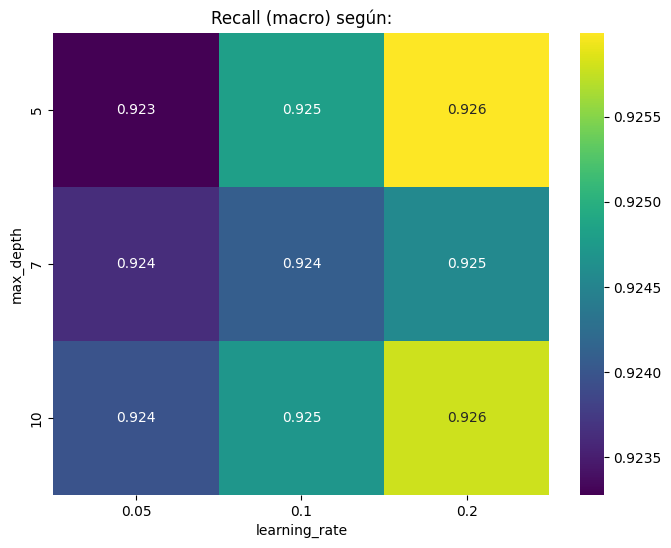

In [283]:
pivot = cv_results_df.pivot_table(index='param_max_depth',
                                  columns='param_learning_rate',
                                  values='mean_test_recall_macro')

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis")
plt.title("Recall (macro) según:")
plt.xlabel("learning_rate")
plt.ylabel("max_depth")
plt.show()

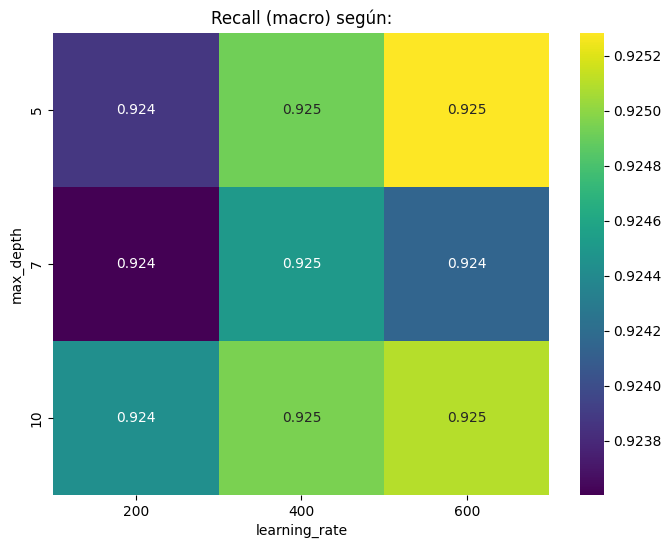

In [284]:
pivot = cv_results_df.pivot_table(index='param_max_depth',
                                  columns='param_n_estimators',
                                  values='mean_test_recall_macro')

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis")
plt.title("Recall (macro) según:")
plt.xlabel("learning_rate")
plt.ylabel("max_depth")
plt.show()

### XGBoost Entrenamiento final

In [60]:
X_train_final = np.vstack((X_train_features, X_val_features))
y_train_final = np.concatenate((y_train_labels, y_val_labels))

print(f"Forma de datos combinados X: {X_train_final.shape}")
print(f"Forma de datos combinados y: {y_train_final.shape}")

Forma de datos combinados X: (87554, 50)
Forma de datos combinados y: (87554,)


In [ ]:
final_xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=num_classes,
    tree_method='hist', 
    device='cuda', 
    random_state=42,
    n_jobs=1,
    learning_rate = 0.4,
    max_depth = 8,
    n_estimators = 800,
    subsample = 0.4,
)

In [270]:
start_time_xgb_final = time.time()

weights = compute_sample_weight(class_weight='balanced', y=y_train_final)
final_xgb_model.fit(X_train_final, y_train_final, sample_weight=weights)

xgb_final_time = time.time() - start_time_xgb_final

In [275]:
y_pred_labels = final_xgb_model.predict(X_test_features)
y_pred_proba = final_xgb_model.predict_proba(X_test_features)

# Calculate evaluation metrics
precision_macro = precision_score(y_test_labels, y_pred_labels, average='macro')
recall_macro = recall_score(y_test_labels, y_pred_labels, average='macro')
accuracy = accuracy_score(y_test_labels, y_pred_labels)
f1_macro = f1_score(y_test_labels, y_pred_labels, average='macro')
cm = confusion_matrix(y_test_labels, y_pred_labels)
auc = roc_auc_score(y_test_labels, y_pred_proba, multi_class='ovr')
report = classification_report(y_test_labels, y_pred_labels)

results = {
    'precision_test': precision_macro,
    'recall_test': recall_macro,
    'accuracy_test': accuracy,
    'f1_score_test': f1_macro,
    'confusion_matrix': cm,
    'y_pred_prob': y_pred_proba,
    'auc_test': auc,
    'classification_report': report,
    'cpu_time': np.nan,
}

joblib.dump(results, f"results/lstm_attention_xgb_classifier_gpu_results.pkl")


['results/lstm_attention_xgb_classifier_gpu_results.pkl']

## Presentación de resultados finales

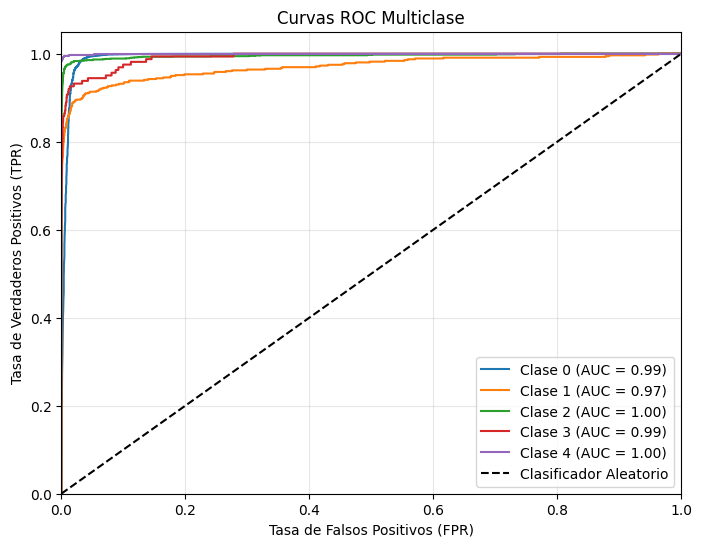

In [286]:
from sklearn.metrics import roc_curve, auc # Dejarlo aquí

# Binarización de las clases
classes = np.unique(y_test_labels)
y_test_bin = label_binarize(y_test_labels, classes=classes)
n_classes = y_test_bin.shape[1]

# Inicialización de diccionarios para almacenar métricas
fpr, tpr, roc_auc = {}, {}, {}

# Cálculo de las curvas ROC y AUC
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'Clase {classes[i]} (AUC = {roc_auc[i]:.2f})')

# Gráfica de la línea diagonal (clasificador aleatorio)
plt.plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio')

# Configuración de la gráfica
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC Multiclase')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

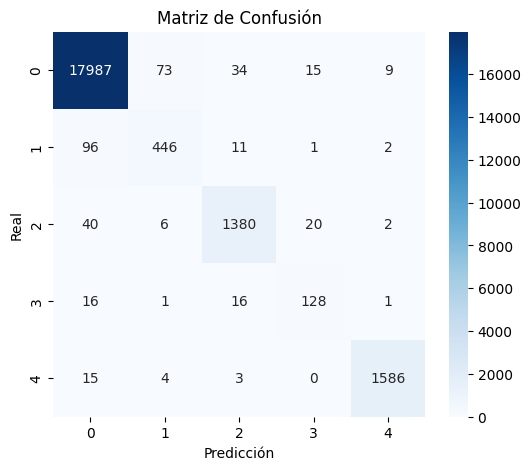

In [287]:
# Matriz de confusión
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

In [289]:
print(report)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     18118
           1       0.84      0.80      0.82       556
           2       0.96      0.95      0.95      1448
           3       0.78      0.79      0.79       162
           4       0.99      0.99      0.99      1608

    accuracy                           0.98     21892
   macro avg       0.91      0.90      0.91     21892
weighted avg       0.98      0.98      0.98     21892



In [290]:
def cargar_resultados(directorio):
    archivos = [f for f in os.listdir(directorio) if f.endswith(".pkl")]
    resultados_totales = []
    for archivo in archivos:
        try:
            data = joblib.load(os.path.join(directorio, archivo))
            if isinstance(data, dict):
                nombre_archivo_sin_extension = os.path.splitext(archivo)[0]
                data["model_name"] = nombre_archivo_sin_extension
                resultados_totales.append(data)
        except Exception as e:
            print(f"Error al cargar el archivo {archivo}: {e}")
    return resultados_totales

resultados_totales = cargar_resultados('results/')

In [295]:
dict_to_df = []

for item in resultados_totales:
    dict_to_df.append({
        "model_name": item["model_name"].split("_results")[0],
        "precission" : item["precision_test"],
        "recall_macro": item["recall_test"],
        "accuracy": item["accuracy_test"],
        "f1_score": item["f1_score_test"],
        "auc": item["auc_test"],
        "total_cpu_time_min": item["cpu_time"]/60,
    })

In [296]:
results_summary = pd.DataFrame(dict_to_df).sort_values(by="recall_macro", ascending=False).reset_index(drop=True)
results_summary

,model_name,precission,recall_macro,accuracy,f1_score,auc,total_cpu_time_min
0,lstm_attention_xgb_classifier_gpu,0.911945,0.904882,0.983327,0.908312,0.990102,NaN
1,cnn,0.942844,0.897814,0.984743,0.918445,0.988604,219.797408
2,lstm,0.938983,0.893313,0.984698,0.914197,0.991004,18.800000
3,mlp,0.904358,0.883581,0.977663,0.893657,0.984824,307.610415
4,xgb,0.959866,0.871120,0.982825,0.910275,0.991387,52.817633
5,knn,0.899565,0.868556,0.976201,0.883464,0.925557,32.473809
6,autoencoder,0.900989,0.855815,0.977298,0.876356,0.987603,458.988292
7,tree,0.831897,0.823717,0.961264,0.827697,0.903896,2.984338
8,svc,0.943355,0.814131,0.977389,0.866491,0.981456,287.041197
9,rf,0.962265,0.812568,0.974831,0.873681,0.992569,56.346595


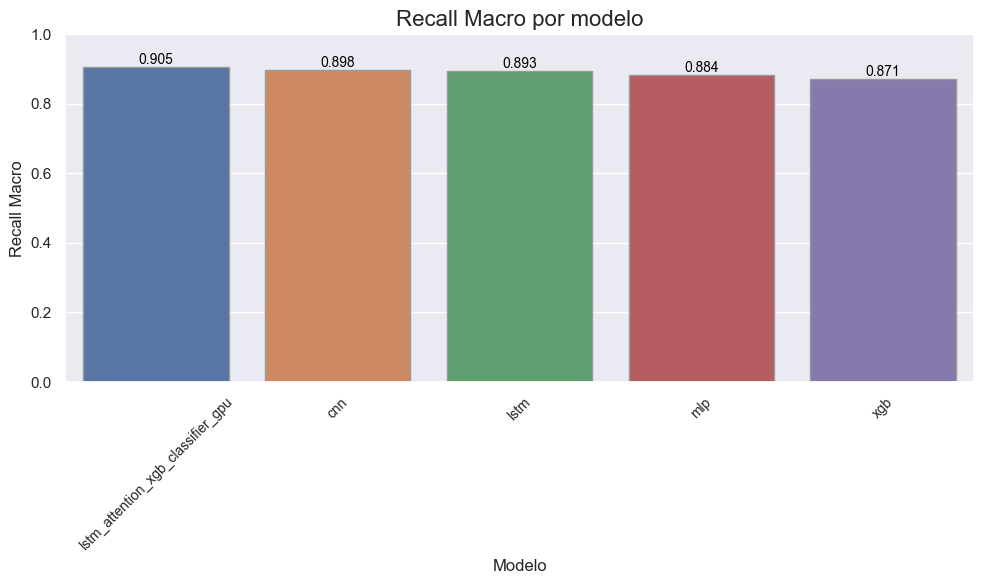

In [301]:
# Estilo de seaborn
sns.set_theme()

# Crear gráfico
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=results_summary.head(5), # Mostrar solo los 5 mejores modelos
    x="model_name", 
    y="recall_macro",
    hue='model_name',
    palette="deep", 
    edgecolor=".6"
)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.3f}',
                (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom',
                fontsize=10, color='black')


plt.title("Recall Macro por modelo", fontsize=16)
plt.xlabel("Modelo", fontsize=12)
plt.ylabel("Recall Macro", fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()